In [13]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import pandas as pd
import os
import matplotlib.cm as cm
from io import StringIO
import sys
import nc_time_axis
import os

sys.path.append('C:/Users/madel/Code/GeoNorth')

from utils import *

In [14]:
site = "TVC"
ctsm_file = f"..\\CTSM_data\\run_1\\merged_files\\{site}_1995-2014.nc"
df = xr.open_dataset(ctsm_file, engine="netcdf4")


tsoi_ctsm = df["TSOI"]
tsoi_ctsm = tsoi_ctsm.resample(time="MS").mean()
ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_TSOI.nc")
tsoi_obs = ds["TSOI"]
tsoi_obs = tsoi_obs.sortby("depth")
tsoi_obs = tsoi_obs.resample(time="MS").mean()

h2osoi_ctsm = df["H2OSOI"]
h2osoi_ctsm = h2osoi_ctsm.resample(time="MS").mean()
ds = xr.open_dataset(f"../Observational_data/{site}_obs/processed/{site}_H2OSOI.nc")
h2osoi_obs = ds["H2OSOI"]
h2osoi_obs = h2osoi_obs.sortby("depth")
h2osoi_obs = h2osoi_obs.resample(time="MS").mean()

C:\Users\madel\AppData\Local\Temp\ipykernel_27084\2547584875.py:3: FutureWarning: In a future version, xarray will not decode the variable 'SNOW_PERSISTENCE' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  df = xr.open_dataset(ctsm_file, engine="netcdf4")


In [16]:
h2osoi_obs

<xarray.DataArray 'H2OSOI' (time: 240, depth: 2)> Size: 4kB
array([[       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
...
       [0.10229099, 0.14352016],
       [0.53430903, 0.377625  ],
       [0.72745901, 0.5453871 ],
       [0.7275457 , 0.55798051],
       [0.75721806, 0.56853819],
       [0.66856183, 0.52739852],
       [0.13447222, 0.24083194],
       [0.1057547 , 0.15699395],
       [0.09817339, 0.14658871],
       [0.09825074, 0.14510714],
       [0.097     , 0.14056989],
       [0.09640972, 0.14029861],
       [0.097     , 0.142     ],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan],
       [       nan,        nan]])
Coordinates:
  * time     (time) object 2kB 1995-01-01 00:00:00 ... 2014-12-01 00:00:00
  * depth    (depth) float64 16B 0.08 0.15
Attributes:
    units:    mm3/mm3

In [17]:
tsoi_obs

<xarray.DataArray 'TSOI' (time: 240, depth: 16)> Size: 31kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(240, 16))
Coordinates:
  * time     (time) object 2kB 1995-01-01 00:00:00 ... 2014-12-01 00:00:00
  * depth    (depth) float64 128B 0.05 0.1 0.101 0.102 ... 0.9 1.04 1.16 1.17
Attributes:
    units:    °C

In [9]:
def final_plot_tsoi(obs, sim, site, depths, vari, show=0):
    obs_daily = obs
    for x in depths:

        plt.figure(figsize=(14,6))

        # Observed (daily)
        plt.plot(
            obs_daily["time"].values,
            obs_daily.sel(depth=x.values, method = "nearest").values,
            label="Observed",
            linewidth=2
        )

        # Simulated
        act_val = round(float(x.values),2)
        plt.plot(
            sim["time"].values,
            sim.sel(depth=act_val, method = "nearest")[f"{vari}"].values,
            label="Simulated",
            linewidth=2
        )

        # Labeling
        remain = int(round(x.values - act_val,3)*1000)
    
        plt.xlabel("Time")
        plt.ylabel(f"{vari}")
        plt.title(f"{vari} at {site} - {act_val*100:.0f}cm")
        plt.grid(True)
        plt.legend()
        #plt.savefig(f"v1.0_final_images/{site}/{vari}/{site}_{vari}_{act_val*100:.0f}cm_{remain}.png")
        if not show:
            plt.close()

In [10]:
da_interp = interpolate_to_depth(df, tsoi_obs.depth)

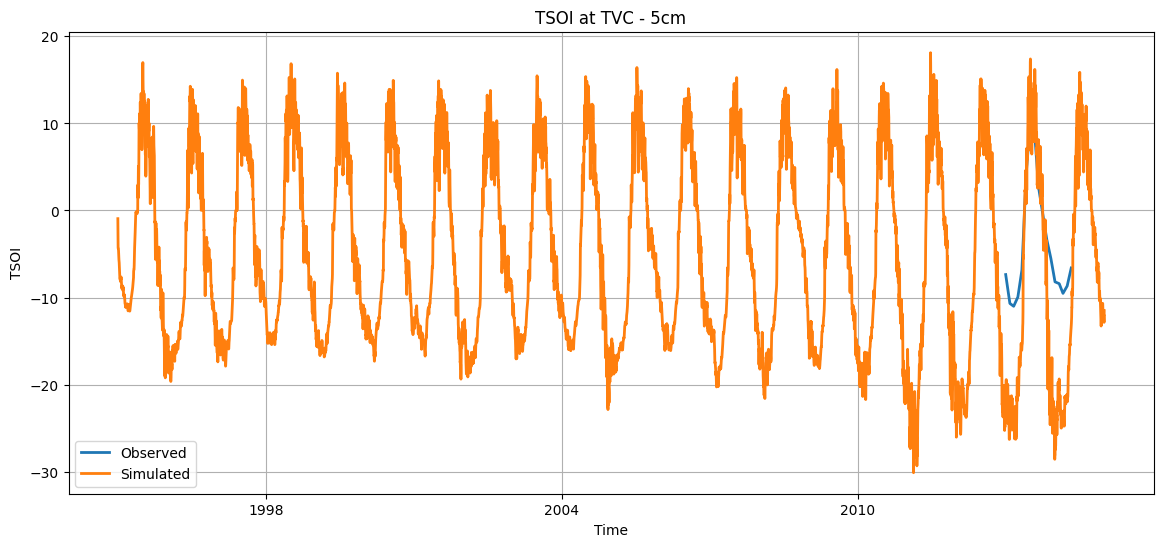

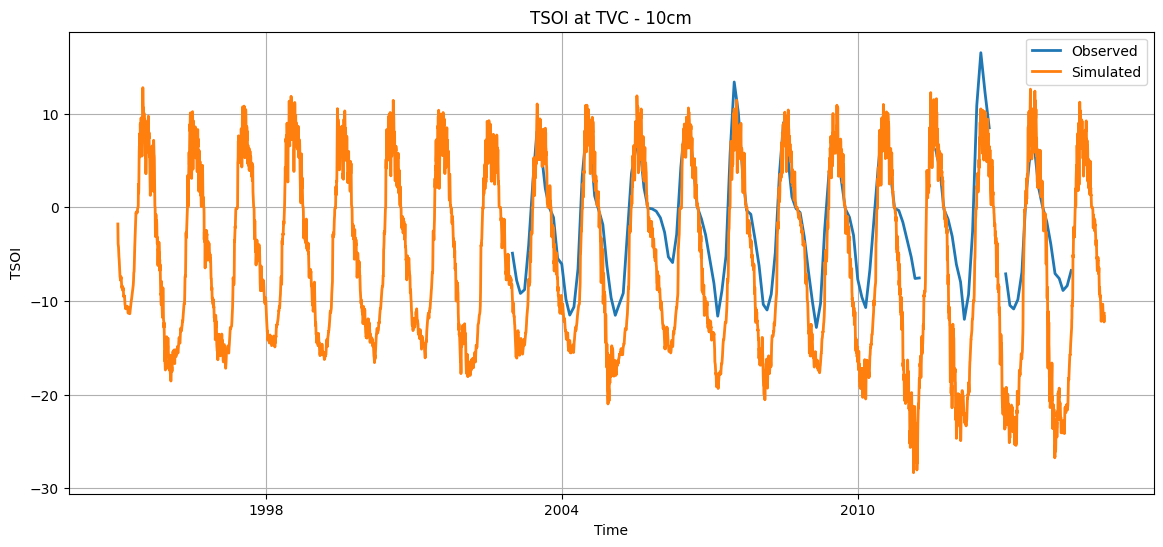

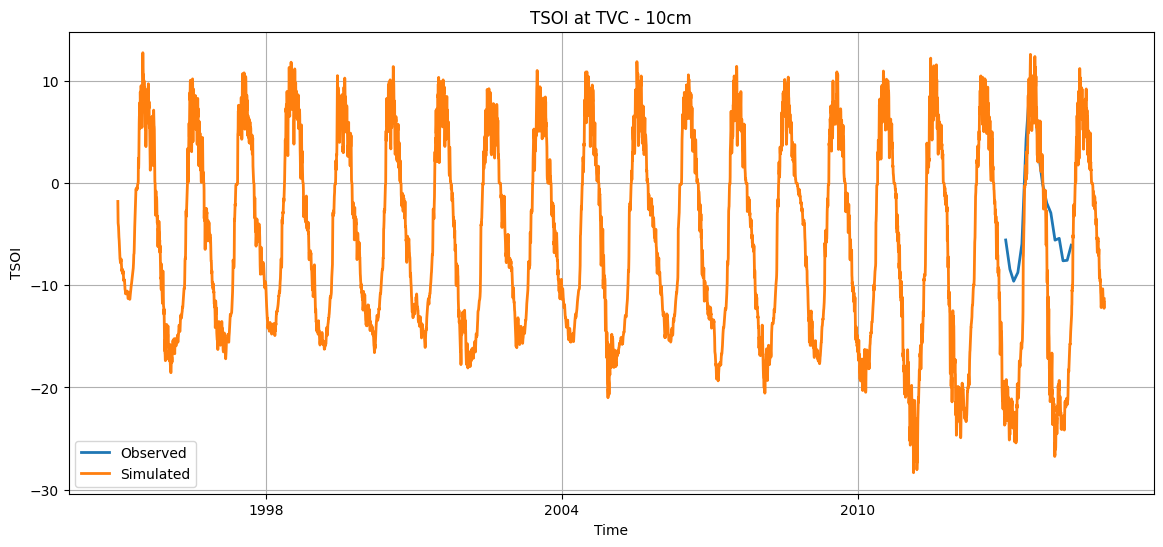

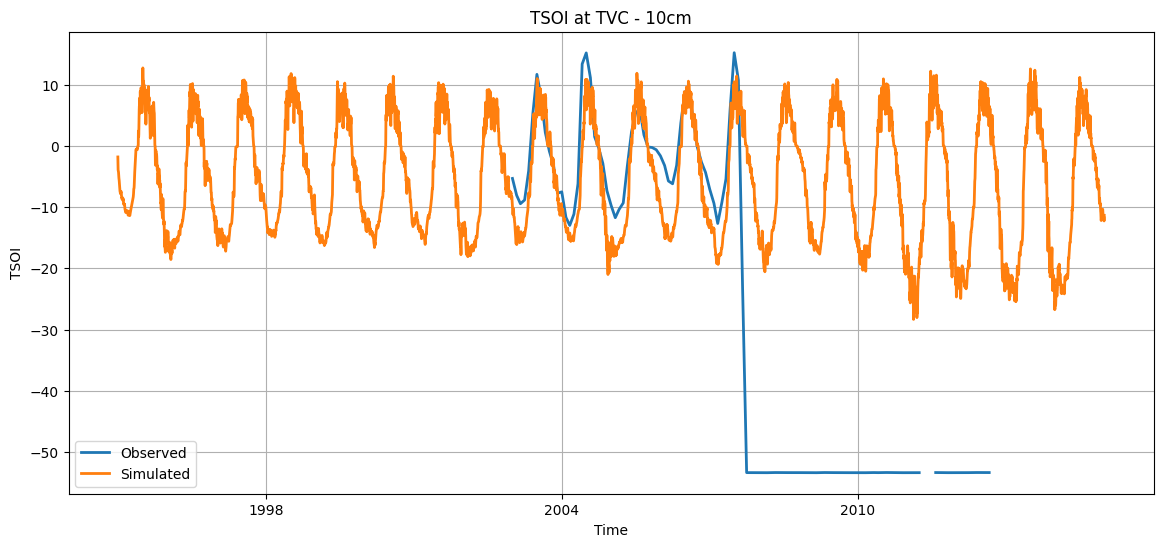

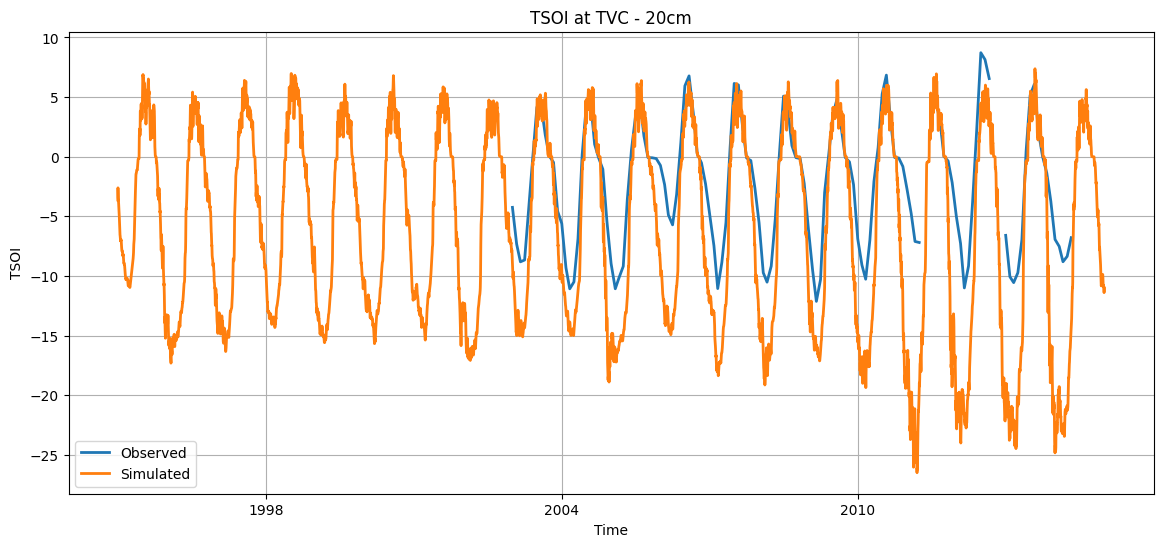

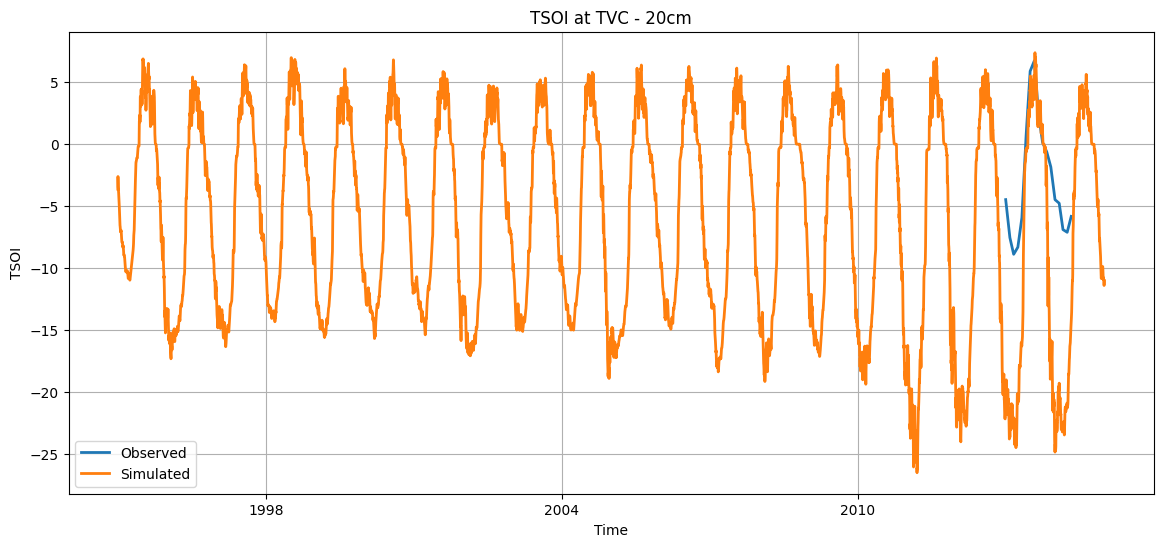

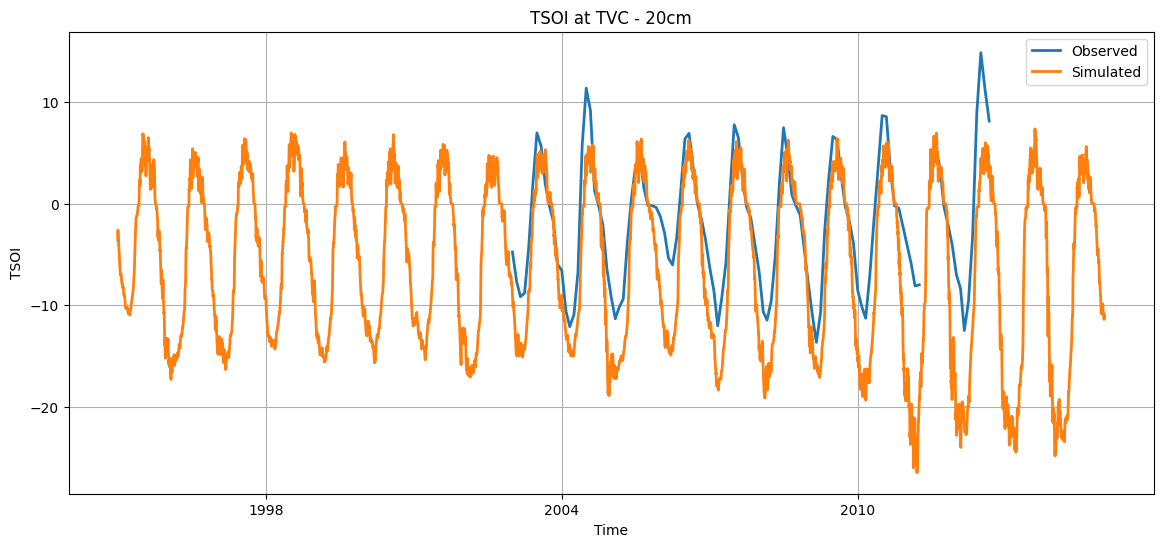

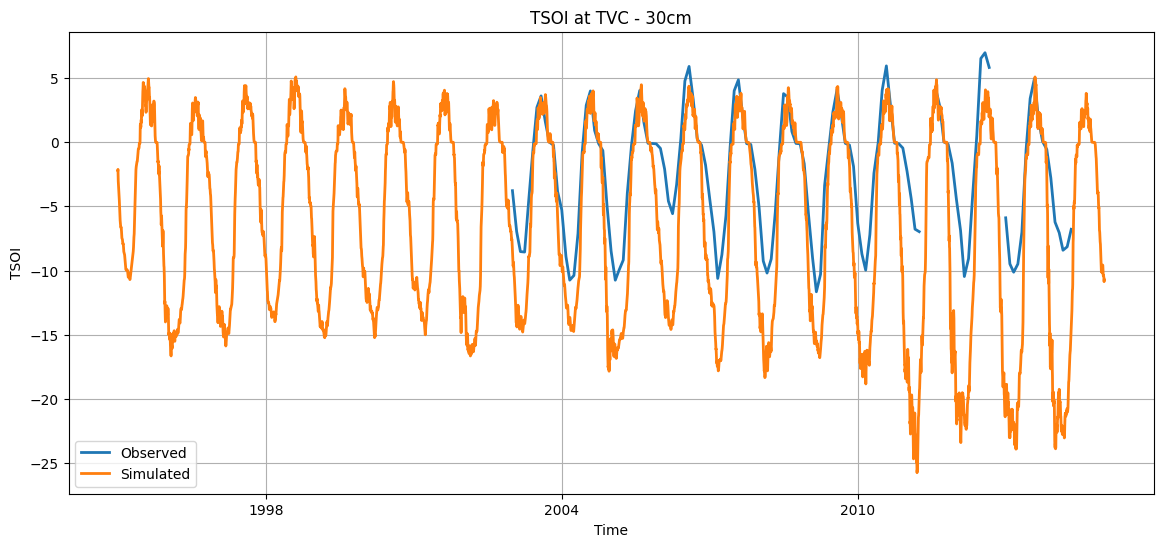

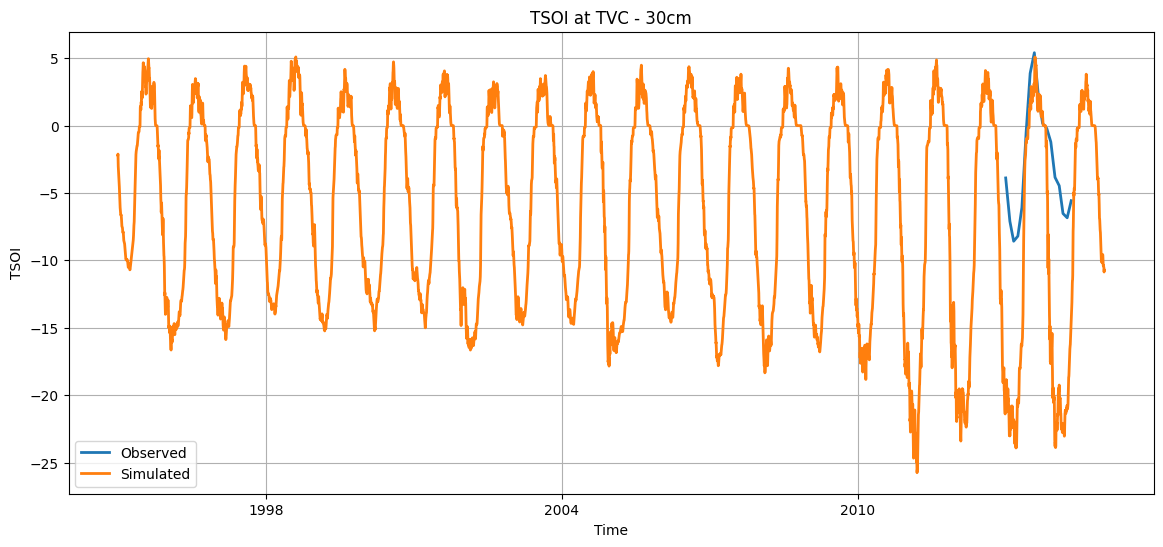

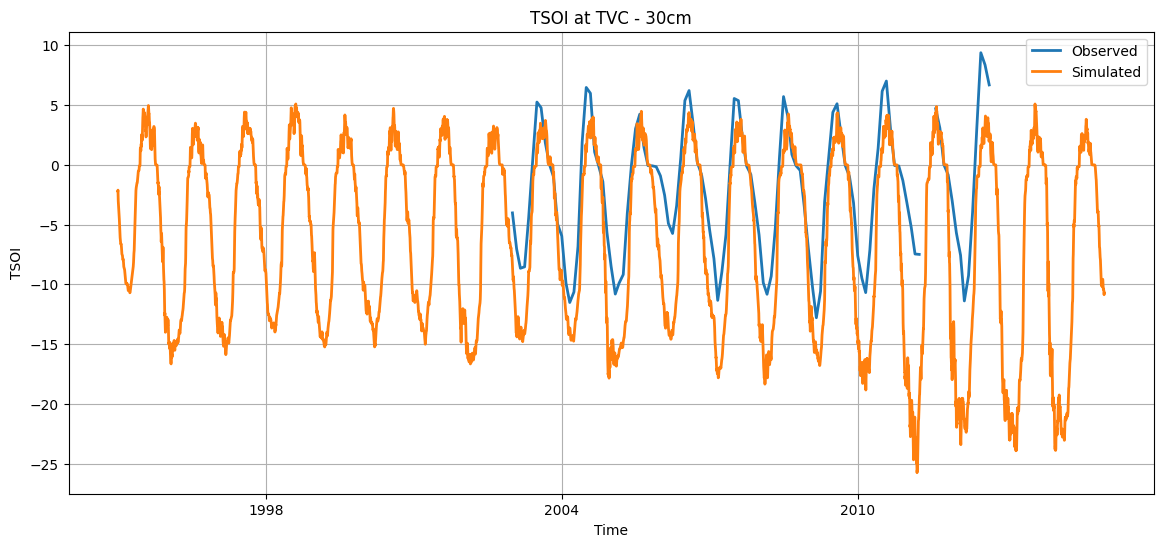

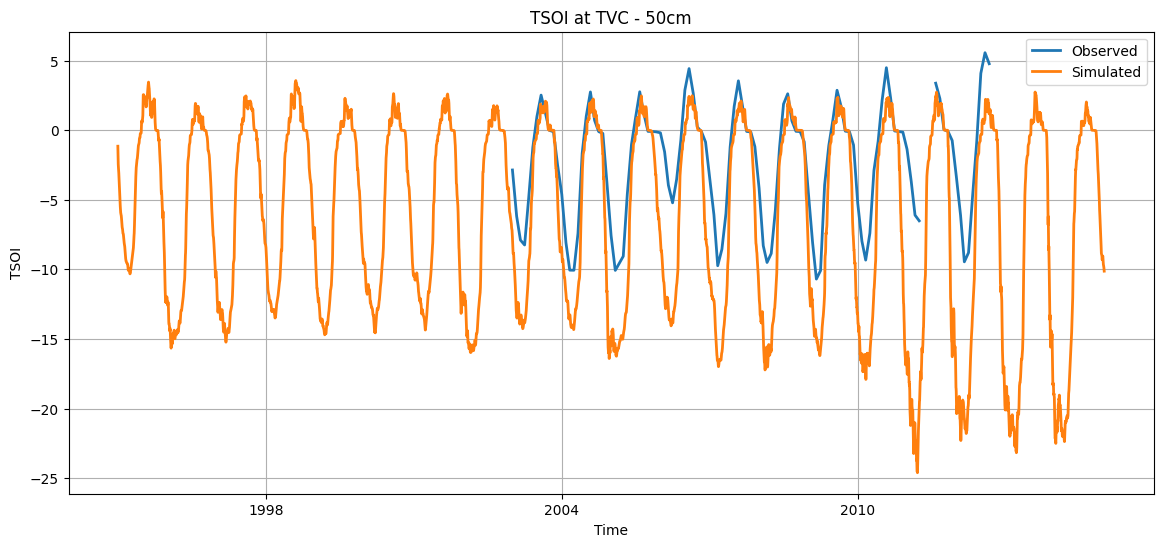

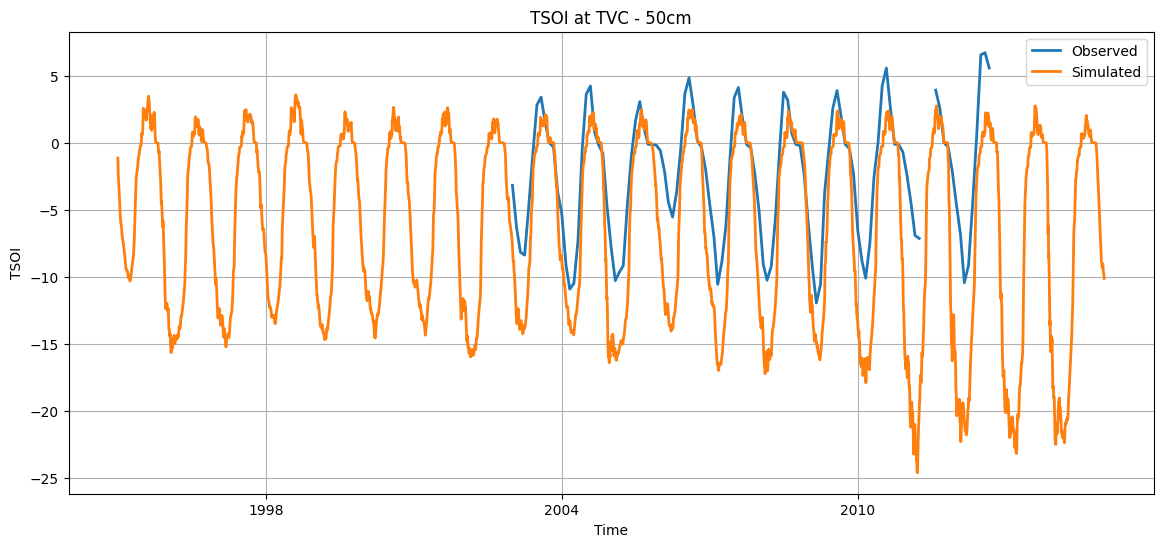

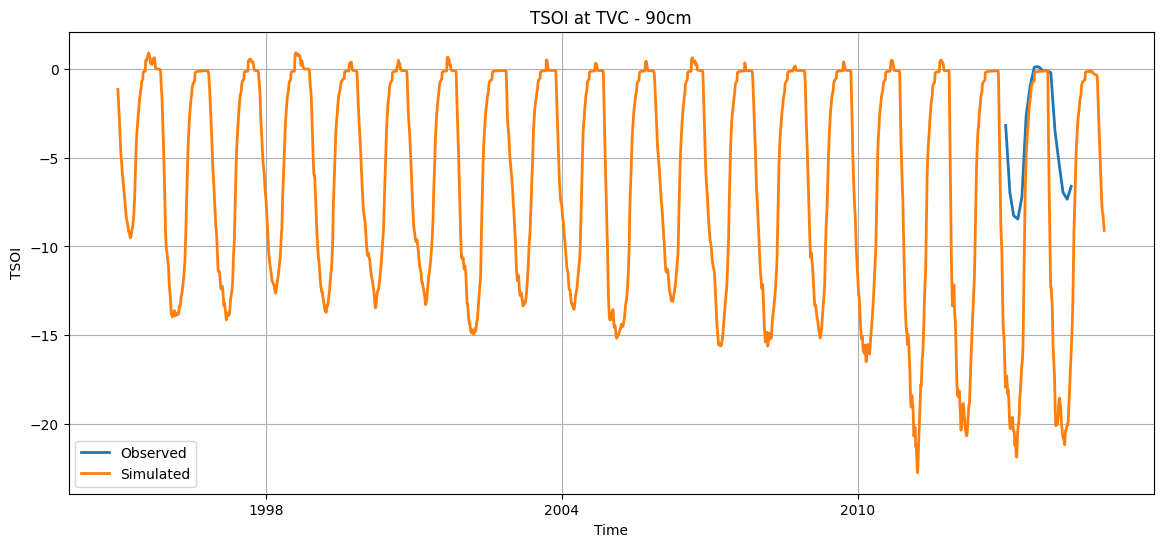

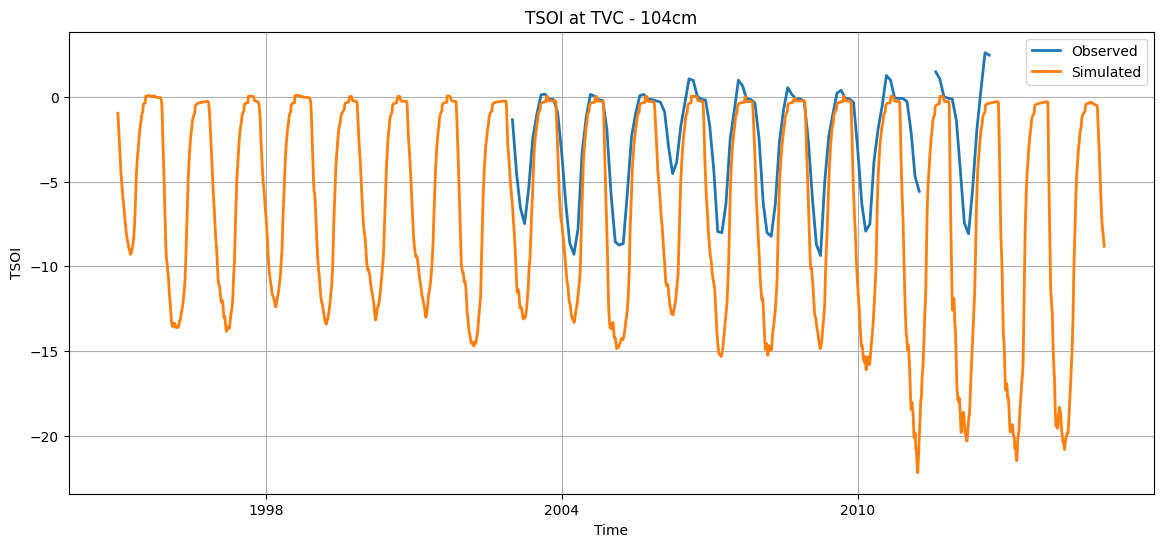

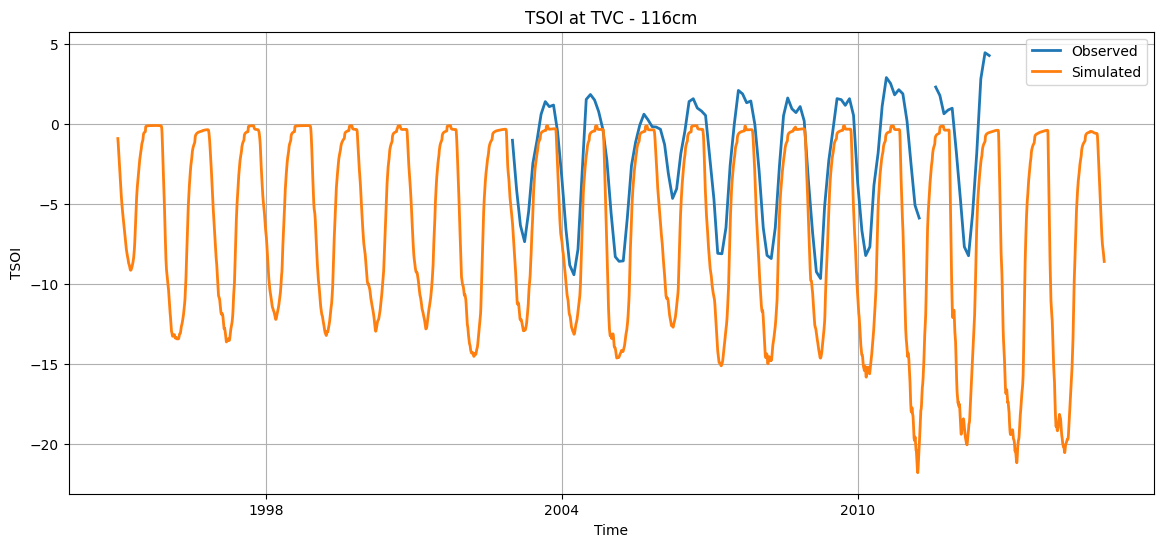

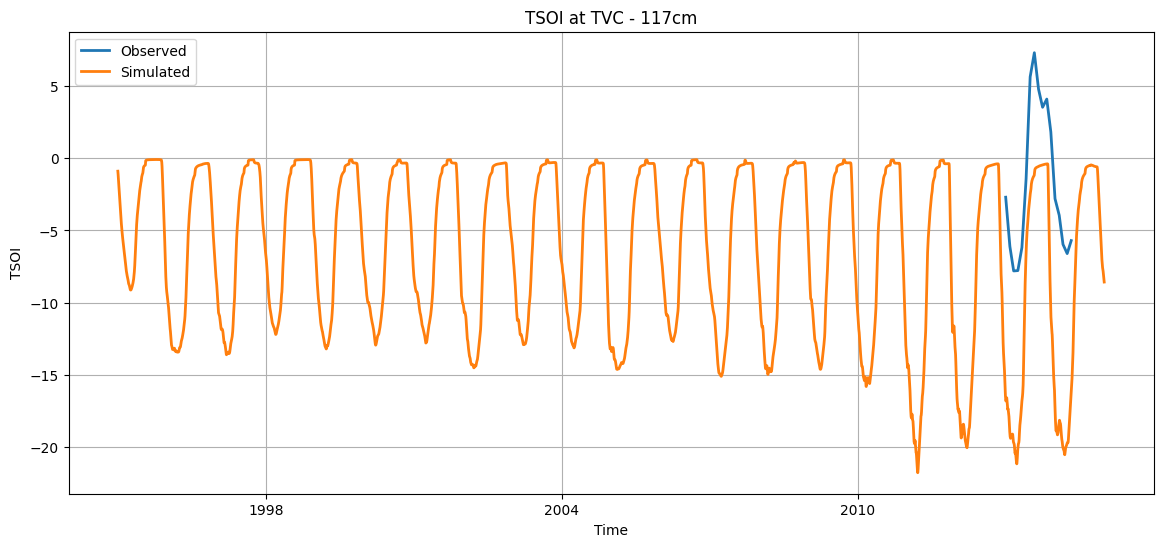

In [12]:
final_plot_tsoi(tsoi_obs, da_interp, site, tsoi_obs.depth, "TSOI", show=1)